# Heavy Rainfall

Analysis of wet-day frequency and extreme (heavy) rainfall days at the selected GHCN station.



```{glue:figure} number_wet_days
:scale: 60%
:align: center
```

```{glue:figure} number_over_95
:scale: 60%
:align: center
```

**Figure. Annual wet days (top) and days with heavy rainfall (bottom) over the period 1951–2024 at Koror.**  Wet days are defined as days above 1mm (0.04 inches).  Heavy rainfall days are defined as days where rainfall is greater than 45.7mm (1.98 inches), the 95th percentile.    The solid black lines represent statistically significant trends (p < 0.05).  The dashed black line represents a trend that is not statistically significant.

## Setup

Import libraries and helper functions from `functions/rainfall.py` and [indicators_setup](https://github.com/lauracagigal/indicators_setup).


In [1]:
import warnings
warnings.filterwarnings("ignore")
import os.path as op
import sys
from pathlib import Path

from myst_nb import glue

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../../../../indicators_setup")
from ind_setup.plotting import plot_bar_probs
from ind_setup.colors import get_df_col
from ind_setup.core import fontsize

sys.path.append("../../functions")
from rainfall import (
    load_site_config,
    site_config_filename,
    build_site_figures_dir,
    build_output_filename,
    persist_heavy_rainfall_outputs,
)


### Define location and variables of interest

Set `site_key` to match the site name used in `00_site_setup.ipynb`.


### Get Data

Load the cached daily `PRCP` pickle from `data/rainfall/GHCN_<station_id>.pkl`.


In [2]:
site_key = "Palau"

site_config_path = Path("../../data/sites") / site_config_filename(site_key)
site_cfg = load_site_config(site_config_path)

site_name = site_cfg.get("site_name", "Site")
site_lon = float(site_cfg["site_lon"])
site_lat = float(site_cfg["site_lat"])
country = site_cfg["country"]
ghcn_station_id = site_cfg["ghcn_station_id"]
ghcn_station_name = site_cfg.get("ghcn_station_name", "")
vars_interest = list(site_cfg.get("vars_interest", ["PRCP"]))
ref_start = str(site_cfg.get("reference_period_start", "1961"))
ref_end = str(site_cfg.get("reference_period_end", "1990"))



In [3]:
data_base_dir = Path("../../data")
site_figures_dir = build_site_figures_dir(Path("../../outputs"), site_name, site_lon, site_lat)
data_dir = Path(data_base_dir, "rainfall")

data_dir.mkdir(parents=True, exist_ok=True)
path_data = str(data_dir)


### Observations from Station


[GHCN-Daily documentation](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/doc/GHCND_documentation.pdf)


The data used for this analysis comes from the [GHCN-Daily](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/) database (NOAA NCEI).

GHCN-Daily provides historical daily precipitation records over global land areas. Records from numerous sources are merged and subjected to quality-assurance reviews. The variable used here is **`PRCP`** (daily precipitation total, mm).

**Data loading:** this notebook reads the pre-processed pickle created by `00_site_setup.ipynb`. It does **not** re-download from NOAA.

**Outputs:** figures → `outputs/figures/<site_tag>/`; tables and JSON → `outputs/tables/<site_tag>/`.


In [4]:
pickle_path = data_dir / f"GHCN_{ghcn_station_id}.pkl"
data = pd.read_pickle(pickle_path)
print(f"Loaded {len(data)} daily records from {pickle_path}")
data_daily = data.copy()


Loaded 26652 daily records from ../../data/rainfall/GHCN_PSW00040309.pkl


#### Wet and dry day classification


Each day is classified as wet (`PRCP ≥ 1 mm`) or dry. Only years with ≥ 300 daily observations are retained before computing annual indicators.


In [5]:
data = data.groupby(data.index.year).filter(lambda x: len(x) >= 300).dropna()

glue("n_years", len(np.unique(data.index.year)), display=False)




In [6]:
data['wet_day'] = np.where(data['PRCP'] >= 1, 1, np.where((np.isnan(data['PRCP'])==True), np.nan, 0))



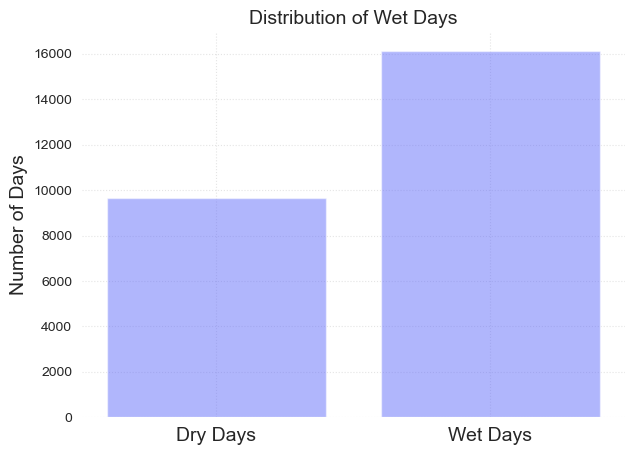

In [7]:
fig, ax = plot_bar_probs(x = [0, 1], y = data.groupby('wet_day').count()['PRCP'].values, labels = ['Dry Days', 'Wet Days'])
ax.set_title('Distribution of Wet Days', fontsize = fontsize)
ax.set_ylabel('Number of Days', fontsize = fontsize)
plt.savefig(
    site_figures_dir / build_output_filename('F7a_Wet_dry_distribution', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)


#### Annual wet-day counts (> 1 mm)


Number of wet days per year with a fitted linear trend. Saved as `F7a_Wet_days_1mm_<site_tag>.png`.


In [8]:
threshold = 1 #np.percentile(data['PRCP'].dropna(), 90)
data['wet_day_t'] = np.where(data['PRCP'] > threshold, 1, np.where((np.isnan(data['PRCP'])==True), np.nan, 0))
data_th_1mm = data.copy()



In [9]:
data_th = data.groupby([data.index.year, data.wet_day_t]).count()['PRCP']
data_th = data_th/data.groupby(data.index.year).count()['PRCP'] * 365



Text(0, 0.5, 'Number of days')

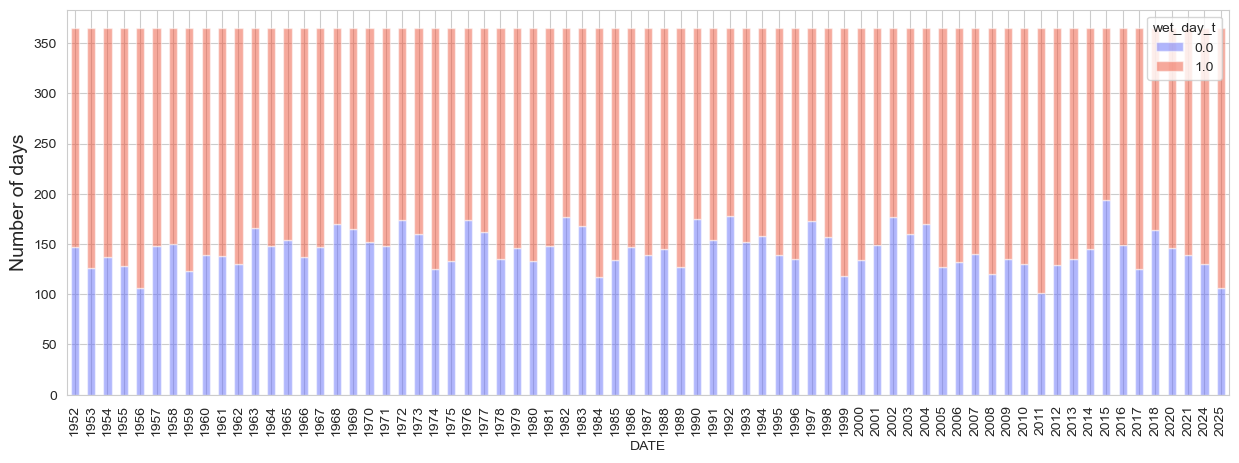

In [10]:
fig, ax = plt.subplots(figsize = [15, 5])
data_th.unstack().plot(kind = 'bar', stacked = True, ax = ax, color = get_df_col()[:2], edgecolor = 'white', alpha = .5)
ax.set_ylabel('Number of days', fontsize = fontsize)



Stacked bar chart of wet and dry days per year (exploratory).


KeyError: "['index'] not in index"

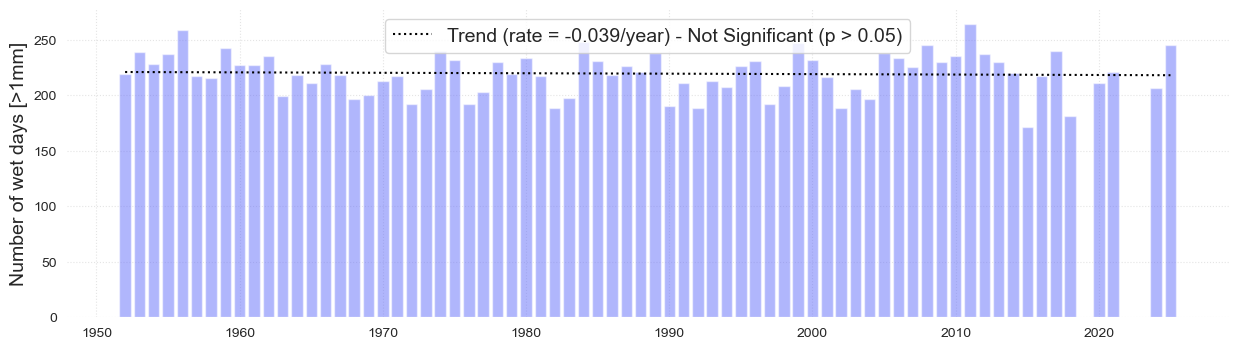

In [11]:
#Wet days
data2 = data.loc[data['wet_day_t'] == 1]
data2 = data2.groupby(data2.index.year).count()
fig, ax, trend_wet = plot_bar_probs(x = data2.index, y = data2.PRCP.values, trendline = True,
               y_label = 'Number of wet days [>1mm]', figsize = [15, 4], return_trend = True)
wet_days_per_year = data2.reset_index()[['index', 'PRCP']].rename(columns={'index': 'year', 'PRCP': 'wet_days'})
plt.savefig(
    site_figures_dir / build_output_filename('F7a_Wet_days_1mm', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)
glue("number_wet_days", fig, display=False)

glue("trend_wet", float(trend_wet), display=False)


## Analysis — heavy rainfall days


### Days above the 95th percentile


**Heavy rainfall day:** daily `PRCP` exceeds the 95th percentile of the full station record. The threshold is computed from all available years and rounded to two decimal places.

This metric tracks changes in the extreme rainfall regime independent of the 1 mm wet-day threshold.


In [ ]:
prcentile = 95
data = data.drop('wet_day', axis = 1)
threshold = np.round(np.percentile(data['PRCP'].dropna(), prcentile), 2)
print(f'Threshold of {threshold}mm')
data['wet_day_t'] = np.where(data['PRCP'] > threshold, 1, np.where((np.isnan(data['PRCP'])==True), np.nan, 0))
data_th_95 = data.copy()



Threshold of 45.2mm


In [ ]:
data_2 = data.loc[data['wet_day_t'] == 1][['PRCP']]
data_over_th = data_2.groupby(data_2.index.year).count()
data_over_th.index = pd.to_datetime(data_over_th.index, format = '%Y')




In [ ]:
data_over_th['PRCP_below'] = 365 - data_over_th['PRCP'].values



In [ ]:
dict_plot = [{'data' : data_over_th, 'var' : 'PRCP', 'ax' : 1, 'label':f'Number of days over threshold: {threshold}mm'},]



In [ ]:
data_over_th



,PRCP,PRCP_below
DATE,,
1952-01-01,25,340
1953-01-01,19,346
1954-01-01,20,345
1955-01-01,9,356
1956-01-01,23,342
...,...,...
2018-01-01,13,352
2020-01-01,17,348
2021-01-01,20,345


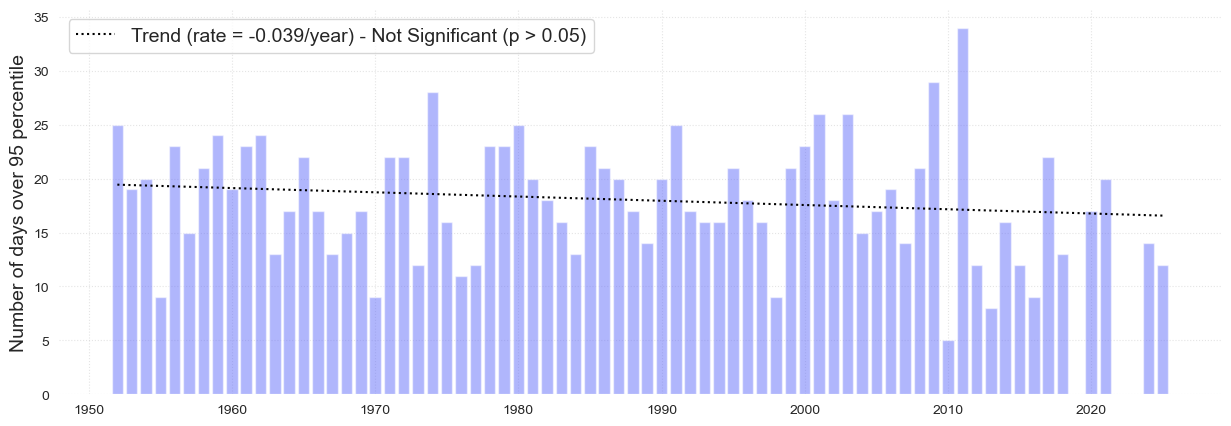

In [ ]:
fig, ax, trend_95 = plot_bar_probs(x = data_over_th.index.year, y = data_over_th['PRCP'].values, trendline = True,
               figsize = (15, 5), return_trend = True, y_label = f'Number of days over {prcentile} percentile')
heavy_days_per_year = data_over_th.reset_index()[['index', 'PRCP']].rename(columns={'index': 'year', 'PRCP': 'heavy_days'})

plt.savefig(
    site_figures_dir / build_output_filename('F7b_Wet_days_95p', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)
glue('number_over_95', fig, display=False)


### Summary table and persisted outputs

Calls `persist_heavy_rainfall_outputs()` to save:

- `R_wet_days_per_year_<site_tag>.csv`
- `R_heavy_days_per_year_<site_tag>.csv`
- `R_heavy_summary_table_<site_tag>.csv`
- `R_heavy_summary_metrics_<site_tag>.json`


In [ ]:
from ind_setup.tables import table_rain_23

summary_table = table_rain_23(data_th_1mm, data_th_95, trend_wet, trend_95)
persist_heavy_rainfall_outputs(
    Path('../../outputs'),
    site_name, site_lon, site_lat,
    ghcn_station_id, ghcn_station_name, country,
    wet_days_per_year, heavy_days_per_year, summary_table,
    trend_wet, trend_95, threshold,
)
